In [1]:
from sklearn.datasets import load_digits

In [5]:
digits = load_digits()
print(digits.data.shape)  
print(digits.target.shape)
print(digits.data[0])
print(digits.target[0])
print(digits.DESCR)


(1797, 64)
(1797,)
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
0
.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bit

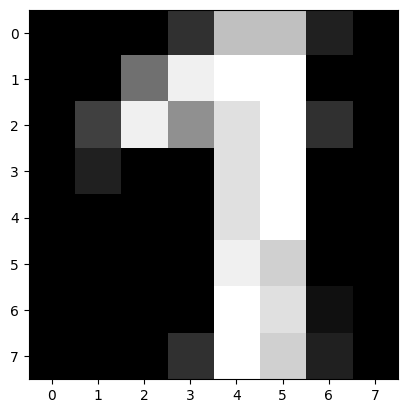

In [11]:
digits.images.shape
import matplotlib.pyplot as plt
plt.imshow(digits.images[1500], cmap='gray')


# preprocessing

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.3, random_state=42)

In [16]:
X_train[0]

array([ 0.,  0.,  5., 13., 13.,  8.,  0.,  0.,  0.,  0., 16., 11., 13.,
       16.,  6.,  0.,  0.,  1., 16.,  5.,  2., 14.,  9.,  0.,  0.,  0.,
        9., 16., 16., 15.,  0.,  0.,  0.,  0., 10., 16., 14., 14.,  0.,
        0.,  0.,  5., 15.,  4.,  0., 16.,  6.,  0.,  0.,  6., 14.,  7.,
        6., 16.,  4.,  0.,  0.,  0.,  7., 15., 16., 10.,  0.,  0.])

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [26]:
X_train[0]

array([0.    , 0.    , 0.3125, 0.8125, 0.8125, 0.5   , 0.    , 0.    ,
       0.    , 0.    , 1.    , 0.6875, 0.8125, 1.    , 0.375 , 0.    ,
       0.    , 0.0625, 1.    , 0.3125, 0.125 , 0.875 , 0.5625, 0.    ,
       0.    , 0.    , 0.5625, 1.    , 1.    , 0.9375, 0.    , 0.    ,
       0.    , 0.    , 0.625 , 1.    , 0.875 , 0.875 , 0.    , 0.    ,
       0.    , 0.3125, 0.9375, 0.25  , 0.    , 1.    , 0.375 , 0.    ,
       0.    , 0.375 , 0.875 , 0.4375, 0.375 , 1.    , 0.25  , 0.    ,
       0.    , 0.    , 0.4375, 0.9375, 1.    , 0.625 , 0.    , 0.    ])


# Performance Merics

In [53]:
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score

def calculate_metrics(y_train, y_test, y_pred_train, y_pred_test):
    acc_train = accuracy_score(y_true=y_train, y_pred=y_pred_train)
    acc_test = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    print(f"accuracy train: {acc_train}")
    print(f"accuracy test: {acc_test}")
    
  
    p_test = precision_score(y_true=y_test, y_pred=y_pred_test,average='weighted')
   
    print(f"precision test: {p_test}")

    
  
    r_test = recall_score(y_true=y_test, y_pred=y_pred_test,average='weighted')
  
    print(f"recall test: {r_test}")

    f1_test = f1_score(y_true=y_test, y_pred=y_pred_test,average='weighted')


    print(f"f1 score test: {f1_test}")
    return acc_train, acc_test, p_test, r_test, f1_test

# Classification

# 1.Random forest


In [54]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=128, random_state=4256)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",128
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)





In [56]:
acc_train_rf, acc_test_rf, p_test_rf, r_test_rf, f1_test_rf = calculate_metrics(y_train, y_test, y_pred_train, y_pred_test)

accuracy train: 1.0
accuracy test: 0.9740740740740741
precision test: 0.9747045132275635
recall test: 0.9740740740740741
f1 score test: 0.9741828967234748


# 2.SVM

In [66]:
from sklearn.svm import SVC
sv = SVC( )
sv.fit(X_train, y_train)
y_pred_train = sv.predict(X_train)
y_pred_test = sv.predict(X_test)

In [67]:
acc_train_sv, acc_test_sv, p_test_sv, r_test_sv, f1_test_sv = calculate_metrics(y_train, y_test, y_pred_train, y_pred_test)


accuracy train: 0.9968178202068417
accuracy test: 0.987037037037037
precision test: 0.9870916487136155
recall test: 0.987037037037037
f1 score test: 0.9870309814097147


# 2.ANN

In [72]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500, random_state=4256,solver='adam', activation='relu',learning_rate_init=0.001)
mlp.fit(X_train, y_train)
y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

In [73]:
acc_train_mlp, acc_test_mlp, p_test_mlp, r_test_mlp, f1_test_mlp = calculate_metrics(y_train, y_test, y_pred_train, y_pred_test)

accuracy train: 1.0
accuracy test: 0.9814814814814815
precision test: 0.9816119085354819
recall test: 0.9814814814814815
f1 score test: 0.9814606863256463


# 3.KNN

In [80]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_train, y_train)
y_pred_train = knn.predict(X_train)


In [81]:
acc_train_knn, acc_test_knn, p_test_knn, r_test_knn, f1_test_knn = calculate_metrics(y_train, y_test, y_pred_train, y_pred_test)

accuracy train: 0.9474940334128878
accuracy test: 0.9814814814814815
precision test: 0.9816119085354819
recall test: 0.9814814814814815
f1 score test: 0.9814606863256463


# Comprasion


<BarContainer object of 4 artists>

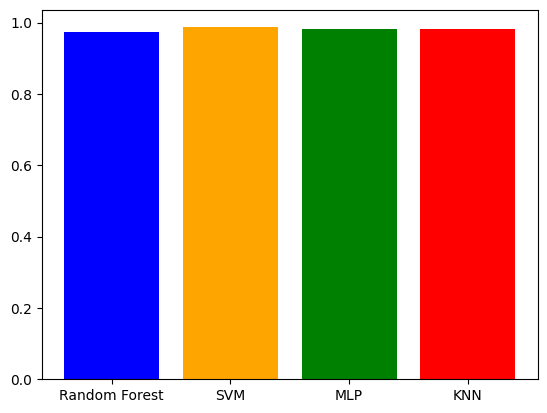

In [93]:
acc_test = [acc_test_rf, acc_test_sv, acc_test_mlp, acc_test_knn]
titles = ['Random Forest', 'SVM', 'MLP', 'KNN']
plt.bar(titles, acc_test, color=['blue', 'orange', 'green', 'red'])


    


<BarContainer object of 4 artists>

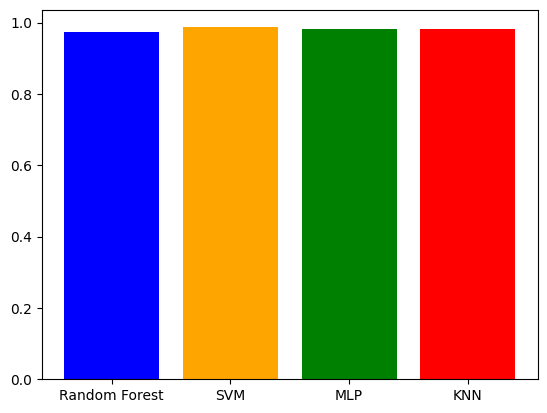

In [94]:
p_test = [p_test_rf, p_test_sv, p_test_mlp, p_test_knn]
plt.bar(titles, p_test, color=['blue', 'orange', 'green', 'red'])


<BarContainer object of 4 artists>

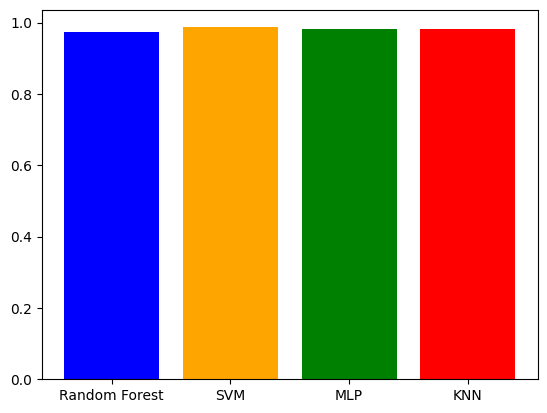

In [95]:
r_test = [r_test_rf, r_test_sv, r_test_mlp, r_test_knn]
plt.bar(titles, r_test, color=['blue', 'orange', 'green', 'red'])
